# NLP - Embeddings, RNNs and LSTMs — Advanced Lab (Classification + Inference)

This notebook combines the two parts of the advanced NLP lab:

* **Part A – Advanced Classification** (`NLP-Advanced-Classification.ipynb`): many-to-one RNN / LSTM / GRU spam classifiers (with and without pretrained GloVe embeddings) and many-to-many POS taggers trained on the Penn TreeBank.
* **Part B – Advanced Inference** (`NLP-Advanced-Inference.ipynb`): loading the saved `h5` POS tagger and tagging unseen text.

**Environment notes**

* The environment runs Python 3.14, for which TensorFlow has no release. We therefore use **Keras 3 with the PyTorch backend** (`KERAS_BACKEND=torch`). The Keras API (`Sequential`, `Embedding`, `SimpleRNN`, `LSTM`, `GRU`, `TimeDistributed`, `pad_sequences`, `to_categorical`, `model.save('*.h5')`) is the same.
* The legacy `keras.preprocessing.text.Tokenizer` was removed in Keras 3, so a small drop-in `Tokenizer` class with the same interface (`fit_on_texts`, `texts_to_sequences`, `word_index`, `index_word`) is defined below.
* `gensim` does not build on Python 3.14; the exercise allows other libraries, so the GloVe vectors (the `glove-wiki-gigaword-100` file from gensim-data) are parsed directly with NumPy.

---
# Part A — Advanced Classification

## Basic Assignment

The notebook will help you practice Many-to-One RNN architecture, as well as Many-to-Many architectures.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"   # TensorFlow is not available for Python 3.14

import re
import gzip
import json
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import nltk
import torch
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Embedding, Dense, Input, TimeDistributed, LSTM, GRU, SimpleRNN
from keras.utils import pad_sequences, to_categorical
from matplotlib import pyplot as plt
from nltk.corpus import treebank
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42
keras.utils.set_random_seed(SEED)

DATA_DIR = Path("../databank")
MODEL_DIR = Path("models")
OUTPUT_DIR = Path("outputs")
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Keras", keras.__version__, "| backend:", keras.backend.backend(), "| torch", torch.__version__)

Keras 3.15.1 | backend: torch | torch 2.14.0+cpu


In [2]:
print("Num GPUs Available: ", torch.cuda.device_count())

Num GPUs Available:  0


In [3]:
class Tokenizer:
    """Minimal replacement for the (removed) keras.preprocessing.text.Tokenizer.

    Words are ranked by frequency; index 0 is reserved for padding and, when
    `oov_token` is given, index 1 is used for out-of-vocabulary words.
    """

    def __init__(self, lower=True, oov_token=None, split_on_whitespace=True):
        self.lower = lower
        self.oov_token = oov_token
        self.split_on_whitespace = split_on_whitespace
        self.word_index, self.index_word = {}, {}
        self.word_counts = Counter()

    def _tokens(self, text):
        if not isinstance(text, str):          # already a list of tokens
            tokens = list(text)
        else:
            tokens = text.split()
        return [t.lower() for t in tokens] if self.lower else tokens

    def fit_on_texts(self, texts):
        for t in texts:
            self.word_counts.update(self._tokens(t))
        vocab = [w for w, _ in self.word_counts.most_common()]
        if self.oov_token is not None:
            vocab = [self.oov_token] + [w for w in vocab if w != self.oov_token]
        self.word_index = {w: i + 1 for i, w in enumerate(vocab)}
        self.index_word = {i: w for w, i in self.word_index.items()}

    def texts_to_sequences(self, texts):
        oov = self.word_index.get(self.oov_token)
        seqs = []
        for t in texts:
            seq = [self.word_index.get(w, oov) for w in self._tokens(t)]
            seqs.append([i for i in seq if i is not None])
        return seqs

    def to_json(self):
        return json.dumps({"lower": self.lower, "oov_token": self.oov_token,
                           "word_index": self.word_index})

    @classmethod
    def from_json(cls, s):
        d = json.loads(s)
        tok = cls(lower=d["lower"], oov_token=d["oov_token"])
        tok.word_index = d["word_index"]
        tok.index_word = {i: w for w, i in tok.word_index.items()}
        return tok

### Loading the dataset
We will work on a binary classification problem. The dataset is of two classes SPAM and NOT SPAM.

In [4]:
dataset = pd.read_csv(DATA_DIR / "spam-1-1.csv", encoding='ISO-8859-1')
dataset = dataset[["v1", "v2"]]          # the trailing unnamed columns are (almost) empty
dataset.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
X=dataset.v2

In [6]:
y=dataset.v1

In [7]:
print(dataset.shape)
print(dataset.v1.value_counts())

(5572, 2)
v1
ham     4825
spam     747
Name: count, dtype: int64


### Exercise 1
Reuse your to_lower(X) function from the NLP basic lab, and the clean_text(X) function to lower case all documents in the dataset and then remove all numerical and special characters from the dataset.

In [8]:
def to_lower(X):
    return X.str.lower()

def clean_text(X):
    # keep only letters and whitespace, then collapse repeated whitespace
    X = X.apply(lambda doc: re.sub(r"[^a-z\s]", " ", doc))
    return X.apply(lambda doc: re.sub(r"\s+", " ", doc).strip())

X = clean_text(to_lower(X))
X.head()

0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in a wkly comp to win fa cup final ...
3          u dun say so early hor u c already then say
4    nah i don t think he goes to usf he lives arou...
Name: v2, dtype: str

### Exercise 2
Create the ground truth vector **y** for the binary classification.
Check that the **y** vector is of shape(ne,1).

In [9]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(dataset.v1).reshape(-1, 1)   # ham -> 0, spam -> 1
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print("y shape:", y.shape)

{'ham': np.int64(0), 'spam': np.int64(1)}
y shape: (5572, 1)


In [10]:
y

array([[0],
       [0],
       [1],
       ...,
       [0],
       [0],
       [0]], shape=(5572, 1))

### Exercise 3
Use Keras' Tokenizer class to vectorize the corpus.
What we expect here is that the tokens will be encoded as integers.


Notice that tokenizing here is different from the tokenization process discussed in the basic lecture.

In [11]:
spam_tokenizer = Tokenizer()
spam_tokenizer.fit_on_texts(X)
X_encoded = spam_tokenizer.texts_to_sequences(X)
vocab_size = len(spam_tokenizer.word_index) + 1     # +1 for the padding index 0
print("Vocabulary size (incl. padding):", vocab_size)

Vocabulary size (incl. padding): 7709


In [12]:
i=25
print(X[i])
print(X_encoded[i])

just forced myself to eat a slice i m really not hungry tho this sucks mark is getting worried he knows i m sick when i turn down pizza lol
[40, 3922, 969, 3, 335, 4, 2731, 1, 26, 163, 28, 761, 637, 41, 1258, 1145, 9, 262, 970, 63, 971, 1, 26, 1048, 46, 1, 1811, 242, 1146, 183]


### Exercise 4
Whether we work with an RNN cell, an LSTM or a GRU cell, we want first to know how many times should we unroll the network. This will be referred to as 'time_steps'.


In this exercise, the goal is to check the lengths of our documents, and then choose a fixed length for all our documents.

Documents which are shorter than the length you fixed will be padded with 0s.

Documents which are longer will be truncated.

a. Check the length of the largest document in the corpus

In [13]:
lengths = [len(seq) for seq in X_encoded]
print("Longest document has", max(lengths), "words")

Longest document has 190 words


b. Check the average count of words in all documents

In [14]:
print("Average word count in our documents is", int(sum(lengths)/len(lengths)))

Average word count in our documents is 15


Quite a distance between the average length and longest document. It's probably worth it to check the lengths in a box plot.

C:\Users\arifu\AppData\Local\Temp\ipykernel_32444\1870194105.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(lengths, vert=False)


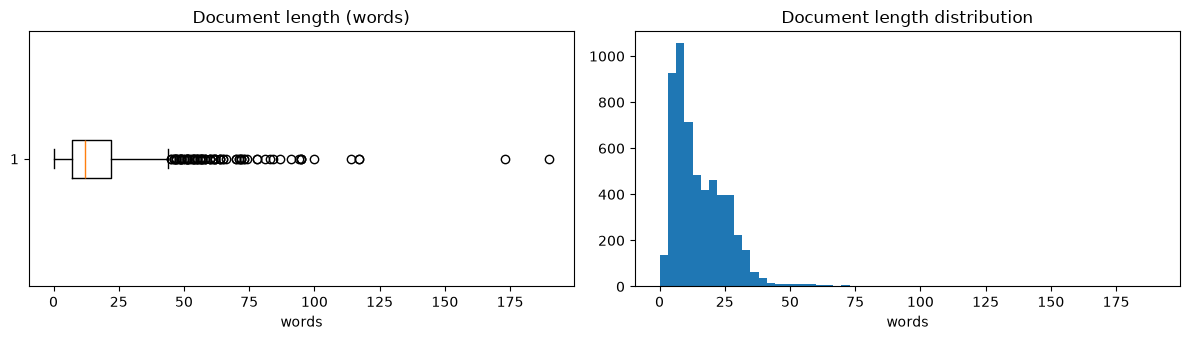

50th percentile: 12 words
90th percentile: 29 words
95th percentile: 33 words
99th percentile: 54 words


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].boxplot(lengths, vert=False)
axes[0].set_title("Document length (words)")
axes[0].set_xlabel("words")
axes[1].hist(lengths, bins=60)
axes[1].set_title("Document length distribution")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.show()

for q in (50, 90, 95, 99):
    print(f"{q}th percentile: {np.percentile(lengths, q):.0f} words")

### Exercise 5

Hopefully, you have chosen a value for the max doc length (which will serve as your time_steps value when you build your RNN).

We can now proceed to use the pad_sequences() method of Keras to pad our sequences, check [here](https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences).

Sentences longer than **n** will be truncated (you can choose to keep the first **n** words or the last).
Sentences shorter than **n** will be padded with 0.

In [16]:
# 99% of the messages have at most ~60 words, so 60 time steps loses almost nothing
# while keeping the unrolled network short. Padding is added *before* the text
# ("pre") so the informative words are the last inputs the RNN sees before the
# many-to-one output; long messages keep their first MAX_LEN words.
MAX_LEN = 60
X_padded = pad_sequences(X_encoded, maxlen=MAX_LEN, padding="pre", truncating="post")
print("X_padded shape:", X_padded.shape)

X_padded shape: (5572, 60)


In [17]:
i=5214
print(X[i])
print(X_encoded[i])
print(X_padded[i])
print(y[i])

natalja f is inviting you to be her friend reply yes or no see her www sms ac u nat stop send stop frnd to
[3828, 705, 9, 1430, 2, 3, 34, 106, 257, 96, 140, 29, 39, 91, 106, 144, 235, 860, 6, 1799, 86, 70, 86, 706, 3]
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0 3828  705    9 1430    2    3   34
  106  257   96  140   29   39   91  106  144  235  860    6 1799   86
   70   86  706    3]
[1]


### Exercise 6

We can now proceed to pass our padded sequences and our **y** vector to an RNN model for training.
Let's first define a simple RNN model.

In [18]:
# split entire data into training and testing sets
TEST_SIZE = 0.25
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=TEST_SIZE, random_state=100)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print("Spam share in test set: %.3f  (accuracy of always predicting 'ham': %.3f)"
      % (y_test.mean(), 1 - y_test.mean()))

(4179, 60) (1393, 60) (4179, 1) (1393, 1)
Spam share in test set: 0.128  (accuracy of always predicting 'ham': 0.872)


**Do check the size of the vocab, needed for the rest of the exercises.**

This dataset was chosen particularly for its small vocab size.

In [19]:
print("vocab_size =", vocab_size)

vocab_size = 7709


In [20]:
# Hyper-parameters and helpers shared by all spam classifiers
EMBEDDING_DIM = 100
RNN_UNITS = 64
EPOCHS = 10
BATCH_SIZE = 64
spam_results = {}

def evaluate_spam(model, name):
    """Report accuracy + spam F1 on the test set (accuracy alone is flattering: ~87% is ham)."""
    proba = model.predict(X_test, verbose=0).ravel()
    pred = (proba >= 0.5).astype(int)
    acc = (pred == y_test.ravel()).mean()
    f1 = f1_score(y_test.ravel(), pred)
    spam_results[name] = {"test_accuracy": acc, "test_spam_f1": f1}
    print(f"{name}: test accuracy = {acc:.4f} | spam F1 = {f1:.4f}")
    print(confusion_matrix(y_test.ravel(), pred))

### Exercise7

Let's first try a classification task using basic RNN cells.

You're free to define the number of units and layers as you see fit.

a. Define the architecture of your model and print its summary.

In [21]:
keras.utils.set_random_seed(SEED)
model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM),
    SimpleRNN(RNN_UNITS),
    Dense(1, activation="sigmoid"),
], name="spam_simple_rnn")
model.summary()

Model: "spam_simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 100)        │       770,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 781,525 (2.98 MB)

 Trainable params: 781,525 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

b. Compile your model.

Use the loss function and the optimizer you want, you don't have to use binary_cross entropy and stochastic gradient descent.

In [22]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["acc"])

c. Train your model

In [23]:
m_history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                      validation_data=(X_test, y_test), verbose=2)
evaluate_spam(model, "SimpleRNN (learned emb.)")

Epoch 1/10


66/66 - 6s - 88ms/step - acc: 0.9239 - loss: 0.2322 - val_acc: 0.9842 - val_loss: 0.0706


Epoch 2/10


66/66 - 5s - 83ms/step - acc: 0.9871 - loss: 0.0449 - val_acc: 0.9864 - val_loss: 0.0534


Epoch 3/10


...

Epoch 9/10


66/66 - 5s - 81ms/step - acc: 0.9995 - loss: 0.0033 - val_acc: 0.9914 - val_loss: 0.0456


Epoch 10/10


66/66 - 6s - 89ms/step - acc: 0.9995 - loss: 0.0025 - val_acc: 0.9914 - val_loss: 0.0452


SimpleRNN (learned emb.): test accuracy = 0.9914 | spam F1 = 0.9655
[[1213    2]
 [  10  168]]


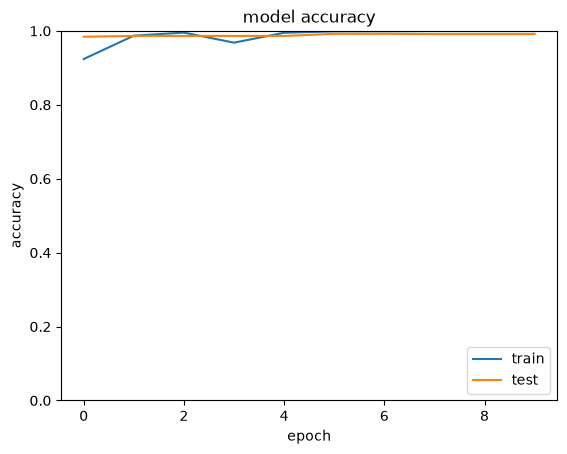

In [24]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

### Exercise 8
Try to perform the same classification task using an LSTM architecture.

a. Define the architecture of your model and print its summary.

In [25]:
keras.utils.set_random_seed(SEED)
model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM),
    LSTM(RNN_UNITS),
    Dense(1, activation="sigmoid"),
], name="spam_lstm")
model.summary()

Model: "spam_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 60, 100)        │       770,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,205 (3.10 MB)

 Trainable params: 813,205 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

b. compile your model.

In [26]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["acc"])

c. Train your model.

In [27]:
m_history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                      validation_data=(X_test, y_test), verbose=2)
evaluate_spam(model, "LSTM (learned emb.)")

Epoch 1/10


66/66 - 4s - 65ms/step - acc: 0.9050 - loss: 0.2856 - val_acc: 0.9770 - val_loss: 0.0781


Epoch 2/10


66/66 - 4s - 65ms/step - acc: 0.9885 - loss: 0.0476 - val_acc: 0.9892 - val_loss: 0.0449


Epoch 3/10


...

Epoch 9/10


66/66 - 4s - 63ms/step - acc: 0.9993 - loss: 0.0026 - val_acc: 0.9885 - val_loss: 0.0575


Epoch 10/10


66/66 - 4s - 67ms/step - acc: 0.9998 - loss: 9.9553e-04 - val_acc: 0.9892 - val_loss: 0.0567


LSTM (learned emb.): test accuracy = 0.9892 | spam F1 = 0.9573
[[1210    5]
 [  10  168]]


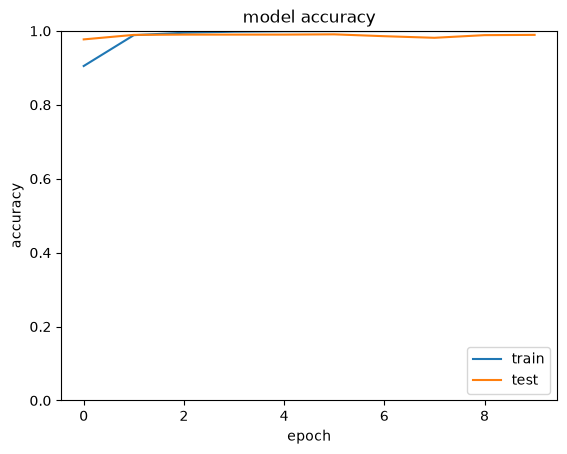

In [28]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

### Exercise 9

Let's now see whether we get different results using a GRU cell.

a. Define the architecture of your model and print its summary.

In [29]:
keras.utils.set_random_seed(SEED)
model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM),
    GRU(RNN_UNITS),
    Dense(1, activation="sigmoid"),
], name="spam_gru")
model.summary()

Model: "spam_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 60, 100)        │       770,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 802,837 (3.06 MB)

 Trainable params: 802,837 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

b. Compile your model

In [30]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["acc"])

c. Train your model

In [31]:
m_history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                      validation_data=(X_test, y_test), verbose=2)
evaluate_spam(model, "GRU (learned emb.)")

Epoch 1/10


66/66 - 5s - 73ms/step - acc: 0.8942 - loss: 0.3084 - val_acc: 0.9792 - val_loss: 0.0670


Epoch 2/10


66/66 - 5s - 69ms/step - acc: 0.9888 - loss: 0.0379 - val_acc: 0.9899 - val_loss: 0.0453


Epoch 3/10


...

Epoch 9/10


66/66 - 4s - 68ms/step - acc: 1.0000 - loss: 3.2162e-04 - val_acc: 0.9914 - val_loss: 0.0653


Epoch 10/10


66/66 - 5s - 69ms/step - acc: 1.0000 - loss: 2.2346e-04 - val_acc: 0.9907 - val_loss: 0.0620


GRU (learned emb.): test accuracy = 0.9907 | spam F1 = 0.9628
[[1212    3]
 [  10  168]]


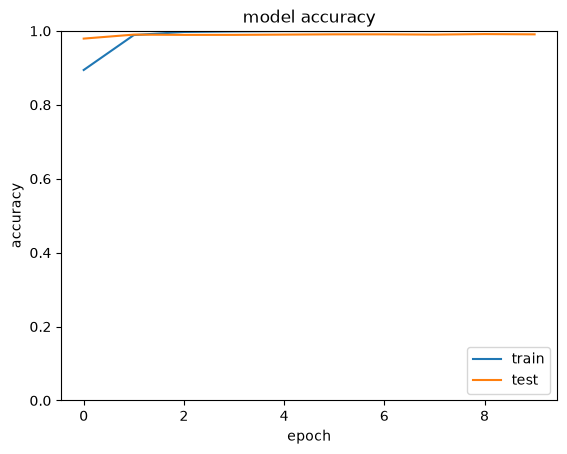

In [32]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

### Exercise 10
It's now time to try training our model using pretrained word embeddings.

a. First, get the pretrained word embeddings of your choice, you can get;

1. You can get Google word2vec from [here](https://code.google.com/archive/p/word2vec/), these embeddings are vectors of size 300
2. You can get Stanford's GloVe embeddings from [here](https://nlp.stanford.edu/projects/glove/), you are offered a choice between embedding vectors of sizes 40, 50, 100, 200 and 300

a. Use the Gensim library to load your embeddings

Feel free to use other libraries also.

*We use Stanford's GloVe 6B vectors of size **100** (Wikipedia + Gigaword, 400k lowercase words), in the word2vec text format distributed by gensim-data. Since gensim cannot be installed on Python 3.14 we read the file directly; it is downloaded once to `../databank/embeddings/`.*

In [33]:
import urllib.request

GLOVE_URL = ("https://github.com/RaRe-Technologies/gensim-data/releases/download/"
             "glove-wiki-gigaword-100/glove-wiki-gigaword-100.gz")
GLOVE_PATH = DATA_DIR / "embeddings" / "glove-wiki-gigaword-100.gz"
if not GLOVE_PATH.exists():
    GLOVE_PATH.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_PATH)

def load_word_vectors(path, keep=None):
    """Load a word2vec-format text file into {word: vector}; optionally only words in `keep`."""
    vectors = {}
    with gzip.open(path, "rt", encoding="utf-8") as f:
        n_words, dim = map(int, f.readline().split())   # header: "<n_words> <dim>"
        for line in f:
            word, rest = line.split(" ", 1)
            if keep is None or word in keep:
                vectors[word] = np.asarray(rest.split(), dtype=np.float32)
    return vectors, n_words, dim

word_vectors, glove_size, GLOVE_DIM = load_word_vectors(GLOVE_PATH, keep=set(spam_tokenizer.word_index))
print(f"GloVe file: {glove_size} words x {GLOVE_DIM} dims; {len(word_vectors)} of them are in our vocab")

GloVe file: 400000 words x 100 dims; 6400 of them are in our vocab


b. If you work with embeddings of size 300 for example, then create a matrix **embeddings**. The shape of the matrix is (vocab_size, embedding_size=300). Each row corresponds to the embeddings of one word in your vocab.

In [34]:
# Row i holds the vector of the word with index i; row 0 (padding) and words
# missing from GloVe stay all-zero.
embeddings = np.zeros((vocab_size, GLOVE_DIM), dtype=np.float32)
for word, idx in spam_tokenizer.word_index.items():
    vec = word_vectors.get(word)
    if vec is not None:
        embeddings[idx] = vec

covered = sum(w in word_vectors for w in spam_tokenizer.word_index)
print(f"Coverage: {covered}/{vocab_size - 1} word types ({covered / (vocab_size - 1):.1%})")
missing = [w for w, _ in spam_tokenizer.word_counts.most_common() if w not in word_vectors][:20]
print("Most frequent words without a GloVe vector:", missing)

Coverage: 6400/7708 word types (83.0%)
Most frequent words without a GloVe vector: ['pobox', 'aight', 'thanx', 'optout', 'chikku', 'mths', 'msgs', 'knw', 'frnd', 'boytoy', 'mobileupd', 'oredi', 'wkly', 'freemsg', 'wq', 'frnds', 'mrng', 'savamob', 'bslvyl', 'txts']


c. Print the embedding_weights shape

In [35]:
embedding_weights = embeddings
print(embedding_weights.shape)

(7709, 100)


### Exercise 11
Let's now retrain our models, Simple RNN, LSTM and GRU using these embeddings.

Let's start by doing it for RNN again.

Define the architecture of your model again, show its summary, compile it and train it.

*The embedding layer is initialised with the GloVe matrix and **frozen** (`trainable=False`), so the recurrent layer has to work with the pretrained semantic space only.*

In [36]:
def pretrained_embedding():
    return Embedding(input_dim=vocab_size, output_dim=GLOVE_DIM,
                     embeddings_initializer=keras.initializers.Constant(embedding_weights),
                     trainable=False)

keras.utils.set_random_seed(SEED)
model = Sequential([
    Input(shape=(MAX_LEN,)),
    pretrained_embedding(),
    SimpleRNN(RNN_UNITS),
    Dense(1, activation="sigmoid"),
], name="spam_simple_rnn_glove")
model.summary()

Model: "spam_simple_rnn_glove"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 60, 100)        │       770,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 781,525 (2.98 MB)

 Trainable params: 10,625 (41.50 KB)

 Non-trainable params: 770,900 (2.94 MB)

In [37]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["acc"])

In [38]:
m_history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                      validation_data=(X_test, y_test), verbose=2)
evaluate_spam(model, "SimpleRNN (GloVe, frozen)")

Epoch 1/10


66/66 - 5s - 80ms/step - acc: 0.8940 - loss: 0.2757 - val_acc: 0.9505 - val_loss: 0.1442


Epoch 2/10


66/66 - 5s - 83ms/step - acc: 0.9591 - loss: 0.1163 - val_acc: 0.9562 - val_loss: 0.1253


Epoch 3/10


...

Epoch 9/10


66/66 - 5s - 82ms/step - acc: 0.9907 - loss: 0.0362 - val_acc: 0.9691 - val_loss: 0.0943


Epoch 10/10


66/66 - 6s - 83ms/step - acc: 0.9878 - loss: 0.0396 - val_acc: 0.9806 - val_loss: 0.0762


SimpleRNN (GloVe, frozen): test accuracy = 0.9806 | spam F1 = 0.9231
[[1204   11]
 [  16  162]]


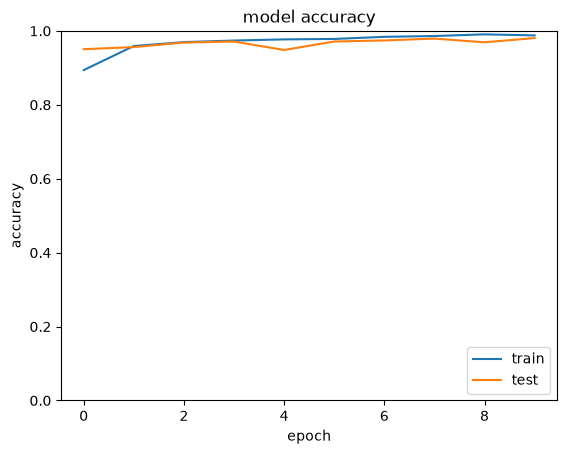

In [39]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

### Exercise 12

Let's now retrain the model with LSTM architecture.

Define the architecture of your model again, show its summary, compile it and train it.

In [40]:
keras.utils.set_random_seed(SEED)
model = Sequential([
    Input(shape=(MAX_LEN,)),
    pretrained_embedding(),
    LSTM(RNN_UNITS),
    Dense(1, activation="sigmoid"),
], name="spam_lstm_glove")
model.summary()

Model: "spam_lstm_glove"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 60, 100)        │       770,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,205 (3.10 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 770,900 (2.94 MB)

In [41]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["acc"])

In [42]:
m_history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                      validation_data=(X_test, y_test), verbose=2)
evaluate_spam(model, "LSTM (GloVe, frozen)")

Epoch 1/10


66/66 - 4s - 59ms/step - acc: 0.9024 - loss: 0.2559 - val_acc: 0.9569 - val_loss: 0.1410


Epoch 2/10


66/66 - 4s - 57ms/step - acc: 0.9696 - loss: 0.0919 - val_acc: 0.9734 - val_loss: 0.0907


Epoch 3/10


...

Epoch 9/10


66/66 - 4s - 59ms/step - acc: 0.9931 - loss: 0.0281 - val_acc: 0.9756 - val_loss: 0.0720


Epoch 10/10


66/66 - 4s - 60ms/step - acc: 0.9943 - loss: 0.0231 - val_acc: 0.9792 - val_loss: 0.0718


LSTM (GloVe, frozen): test accuracy = 0.9792 | spam F1 = 0.9188
[[1200   15]
 [  14  164]]


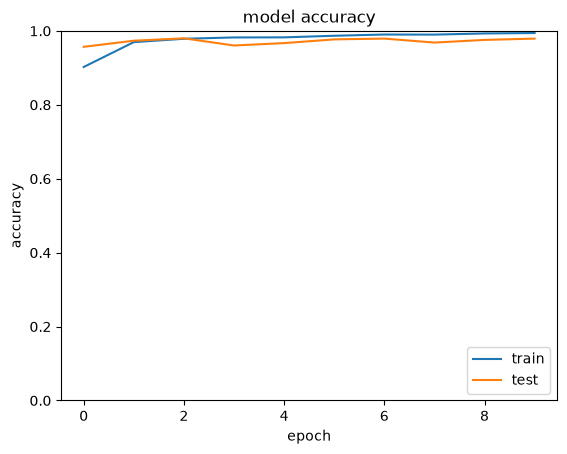

In [43]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

### Exercise 13

Let's now retrain the model with GRU architecture.

Define the architecture of your model again, show its summary, compile it and train it.

In [44]:
keras.utils.set_random_seed(SEED)
model = Sequential([
    Input(shape=(MAX_LEN,)),
    pretrained_embedding(),
    GRU(RNN_UNITS),
    Dense(1, activation="sigmoid"),
], name="spam_gru_glove")
model.summary()

Model: "spam_gru_glove"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 60, 100)        │       770,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 802,837 (3.06 MB)

 Trainable params: 31,937 (124.75 KB)

 Non-trainable params: 770,900 (2.94 MB)

In [45]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["acc"])

In [46]:
m_history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                      validation_data=(X_test, y_test), verbose=2)
evaluate_spam(model, "GRU (GloVe, frozen)")

Epoch 1/10


66/66 - 4s - 63ms/step - acc: 0.8674 - loss: 0.3101 - val_acc: 0.9296 - val_loss: 0.2018


Epoch 2/10


66/66 - 4s - 64ms/step - acc: 0.9653 - loss: 0.1146 - val_acc: 0.9691 - val_loss: 0.0921


Epoch 3/10


...

Epoch 9/10


66/66 - 4s - 64ms/step - acc: 0.9928 - loss: 0.0283 - val_acc: 0.9856 - val_loss: 0.0537


Epoch 10/10


66/66 - 4s - 63ms/step - acc: 0.9957 - loss: 0.0191 - val_acc: 0.9878 - val_loss: 0.0530


GRU (GloVe, frozen): test accuracy = 0.9878 | spam F1 = 0.9507
[[1212    3]
 [  14  164]]


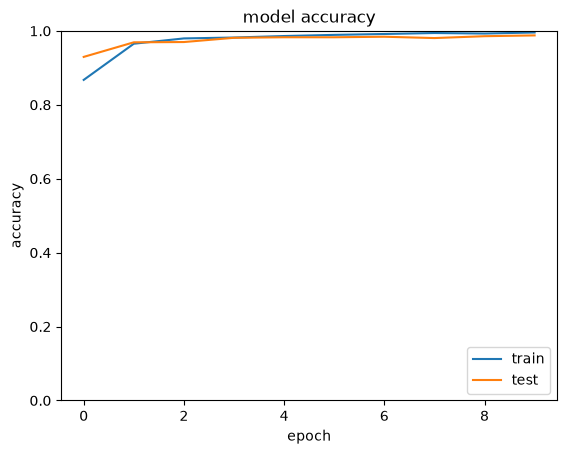

In [47]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

#### Comparison of the spam classifiers

In [48]:
spam_summary = pd.DataFrame(spam_results).T.sort_values("test_spam_f1", ascending=False)
spam_summary.round(4)

,test_accuracy,test_spam_f1
SimpleRNN (learned emb.),0.9914,0.9655
GRU (learned emb.),0.9907,0.9628
LSTM (learned emb.),0.9892,0.9573
"GRU (GloVe, frozen)",0.9878,0.9507
"SimpleRNN (GloVe, frozen)",0.9806,0.9231
"LSTM (GloVe, frozen)",0.9792,0.9188


**Discussion.** Because ~87% of the messages are *ham*, a trivial classifier already reaches ~0.87 accuracy, so the spam F1 score is the more informative number.

* **All three cell types do very well with learned embeddings** (accuracy ≈ 0.99, spam F1 ≈ 0.96). The differences between SimpleRNN, LSTM and GRU are within a few misclassified messages, i.e. within run-to-run noise. The task is short and very separable: spam is recognisable from a few keywords (*free*, *claim*, *prize*, *txt*, *mobile*), and with `"pre"` padding those words sit close to the output step, so the SimpleRNN's weakness with long-range dependencies (vanishing gradients) hardly matters here.
* **Frozen GloVe embeddings are slightly worse** (F1 0.92–0.95). Only 83% of the vocabulary has a GloVe vector, and the missing words are exactly the SMS-specific ones (*pobox*, *optout*, *freemsg*, *txts*, *wkly*, ...) that are strong spam cues. They all collapse to a zero vector, and because the embedding is frozen the model cannot learn them. Learned embeddings, on the other hand, are tailored to this corpus.
* With frozen embeddings the **GRU is the best** of the three. When the input representation is fixed, the gating helps the recurrent layer select the relevant words.
* Pretrained embeddings would pay off more with less training data or a larger vocabulary of *standard* English, or when fine-tuned (`trainable=True`) instead of frozen.

## Regular Assignment
### Exercise 14

By now, hopefully the many-to-one RNN type makes sense. Let's now try a diffrent type, many-to-many.

We wish to build our own POS tagger. Recall how POS tags help us understand a first layer of the syntactic structure of a given sentence.

There are various ways with which you can build a POS tagger. A rule-based one, a probabilistic one, using Hidden Markov Models (HMMs). There's also an option to build a statistical model to learn a POS tagger.

We'll try the statistical approach. The training data is abundant, available through NLTK even.

We'll first acquire the TreeBank dataset.

In [49]:
#You might need to download the dataset first
nltk.download('treebank', quiet=True)
nltk.download('universal_tagset', quiet=True)

True

In [50]:
corpus = treebank.tagged_sents(tagset='universal')

Notice that each entry in the dataset is a tuple (word, pos_tag). We want our training **X** to have the words of the sentence, and **Y** to have the equivalent POS tags.

In [51]:
i=25
print(type(corpus[i]))
print(corpus[i])

<class 'list'>
[('By', 'ADP'), ('1997', 'NUM'), (',', '.'), ('almost', 'ADV'), ('all', 'DET'), ('remaining', 'VERB'), ('uses', 'NOUN'), ('of', 'ADP'), ('cancer-causing', 'ADJ'), ('asbestos', 'NOUN'), ('will', 'VERB'), ('be', 'VERB'), ('outlawed', 'VERB'), ('*-6', 'X'), ('.', '.')]


a. Create your frame X which has all the sentences, and a frame Y with all the POS tags.

In [52]:
X = [[word for word, tag in sentence] for sentence in corpus]
Y = [[tag for word, tag in sentence] for sentence in corpus]

In [53]:
i=0
print(X[i])
print(Y[i])

['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']
['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'NUM', '.']


### Exercise 15

Check that you have the same number of entries in X and Y.

Check also that every entry in X, has the same number of elements as in its equivalent of Y.

If a sentence in X has 5 tokens, we need to have 5 POS tags in Y.

In [54]:
print("Sentences in X:", len(X), "| tag sequences in Y:", len(Y))
assert len(X) == len(Y)
mismatches = [i for i, (xs, ys) in enumerate(zip(X, Y)) if len(xs) != len(ys)]
print("Sentences whose token count differs from their tag count:", len(mismatches))
assert not mismatches

Sentences in X: 3914 | tag sequences in Y: 3914
Sentences whose token count differs from their tag count: 0


3914 sentences is enough training data for our model.

### Exercise 16

a. Let's now move on to convert X and Y both to integers, using Keras's tokenizer.

*Words are lower-cased and an out-of-vocabulary token `<OOV>` is reserved (index 1): at inference time (Part B) the tagger will meet words that are not in the TreeBank vocabulary, and they must still map to a valid index. Tags are kept as they are (no lower-casing, punctuation tag `.` preserved).*

In [55]:
word_tokenizer = Tokenizer(lower=True, oov_token="<OOV>")
word_tokenizer.fit_on_texts(X)
X_encoded = word_tokenizer.texts_to_sequences(X)

tag_tokenizer = Tokenizer(lower=False)
tag_tokenizer.fit_on_texts(Y)
Y_encoded = tag_tokenizer.texts_to_sequences(Y)

print(X[0]); print(X_encoded[0])
print(Y[0]); print(Y_encoded[0])

['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']
[5602, 3747, 2, 2025, 87, 332, 2, 47, 2406, 3, 132, 28, 7, 2026, 333, 460, 2027, 4]
['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'NUM', '.']
[1, 1, 3, 8, 1, 7, 3, 2, 2, 5, 1, 4, 5, 7, 1, 1, 8, 3]


a. Let's print the size of the vocab, also the number of different POS tags we have.

We need to know how many different POS tags we have, because that should be our number of classes.

In [56]:
pos_vocab_size = len(word_tokenizer.word_index) + 1   # + padding index 0
num_tags = len(tag_tokenizer.word_index)
num_classes = num_tags + 1                            # + padding class 0
print("Vocabulary size (incl. padding + OOV):", pos_vocab_size)
print("Number of POS tags:", num_tags, sorted(tag_tokenizer.word_index))
print("Number of output classes (tags + padding):", num_classes)

Vocabulary size (incl. padding + OOV): 11389
Number of POS tags: 12 ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']
Number of output classes (tags + padding): 13


### Exercise 17

Let's again pad our sentences and our tags. We, again, need to decide on our max length, a decision that is crucial as this matches the number of time steps for our RNN architecture

Longest sentence: 271 | mean: 25.7
95th percentile: 47 tokens
99th percentile: 58 tokens
99.9th percentile: 94 tokens


C:\Users\arifu\AppData\Local\Temp\ipykernel_32444\1950426495.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(sent_lengths, vert=False)


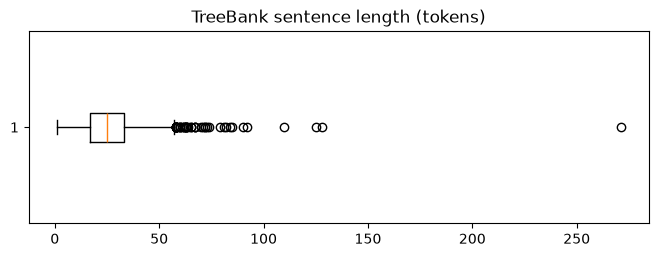

In [57]:
sent_lengths = [len(s) for s in X]
print("Longest sentence:", max(sent_lengths), "| mean: %.1f" % np.mean(sent_lengths))
for q in (95, 99, 99.9):
    print(f"{q}th percentile: {np.percentile(sent_lengths, q):.0f} tokens")

plt.figure(figsize=(8, 2.5))
plt.boxplot(sent_lengths, vert=False)
plt.title("TreeBank sentence length (tokens)")
plt.show()

In [58]:
# 100 time steps covers >99.9% of the sentences completely; only a handful of
# very long ones get truncated. Here padding goes *after* the sentence ("post")
# so that time step t lines up with token t, and the padding is masked out.
POS_MAX_LEN = 100
X_padded = pad_sequences(X_encoded, maxlen=POS_MAX_LEN, padding="post", truncating="post")
Y_padded = pad_sequences(Y_encoded, maxlen=POS_MAX_LEN, padding="post", truncating="post")
print(X_padded.shape, Y_padded.shape)
print("Sentences truncated:", sum(l > POS_MAX_LEN for l in sent_lengths))

(3914, 100) (3914, 100)
Sentences truncated: 4


In [59]:
i=0
print(X_padded[i])
print(Y_padded[i])

[5602 3747    2 2025   87  332    2   47 2406    3  132   28    7 2026
  333  460 2027    4    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[1 1 3 8 1 7 3 2 2 5 1 4 5 7 1 1 8 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Exercise 18

Try a first version of your RNN models without using any pretrained embeddings.

a. Let's one-hot encode Y

In [60]:
Y = to_categorical(Y_padded, num_classes=num_classes)
print(Y.shape)   # (sentences, time steps, classes)

(3914, 100, 13)


b. We create a train and test set.

In [61]:
# split entire data into training and testing sets
TEST_SIZE = 0.20
X_train, X_test, y_train, y_test = train_test_split(X_padded, Y, test_size=TEST_SIZE, random_state=100)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3131, 100) (783, 100) (3131, 100, 13) (783, 100, 13)


c. Define your RNN model, using a simple RNN. Compile it and fit it to the data.

Do not forget to wrap your Dense output layer with the TimeDistributed wrapper. We're doing a multiclassification at each time step.

*`mask_zero=True` in the embedding layer makes the recurrent layer, the loss and the metric ignore padded positions. Without it roughly 75% of all time steps are padding and the "accuracy" would be dominated by correctly predicting padding. We additionally report the token-level accuracy on real tokens only with `pos_token_accuracy`.*

In [62]:
POS_EMB_DIM = 100
POS_UNITS = 64
POS_EPOCHS = 10
pos_results = {}

def build_tagger(rnn_layer, name):
    keras.utils.set_random_seed(SEED)
    return Sequential([
        Input(shape=(POS_MAX_LEN,)),
        Embedding(input_dim=pos_vocab_size, output_dim=POS_EMB_DIM, mask_zero=True),
        rnn_layer,
        TimeDistributed(Dense(num_classes, activation="softmax")),
    ], name=name)

def pos_token_accuracy(model, X_eval, y_eval):
    """Accuracy over real (non-padding) tokens."""
    pred = model.predict(X_eval, verbose=0).argmax(-1)
    true = y_eval.argmax(-1)
    mask = X_eval != 0
    return (pred[mask] == true[mask]).mean()

model = build_tagger(SimpleRNN(POS_UNITS, return_sequences=True), "pos_simple_rnn")
model.summary()

Model: "pos_simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 100)       │     1,138,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 100, 64)        │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 13)        │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,305 (4.39 MB)

 Trainable params: 1,150,305 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])

In [64]:
m_history = model.fit(X_train, y_train, epochs=POS_EPOCHS, batch_size=BATCH_SIZE,
                      validation_data=(X_test, y_test), verbose=2)
pos_results["SimpleRNN"] = pos_token_accuracy(model, X_test, y_test)
print("Test token accuracy (non-padding): %.4f" % pos_results["SimpleRNN"])
pos_models = {"SimpleRNN": model}

Epoch 1/10


49/49 - 12s - 237ms/step - acc: 0.3587 - loss: 2.1137 - val_acc: 0.5848 - val_loss: 1.6947


Epoch 2/10


49/49 - 11s - 230ms/step - acc: 0.7319 - loss: 1.1704 - val_acc: 0.8128 - val_loss: 0.7844


Epoch 3/10


...

Epoch 9/10


49/49 - 11s - 230ms/step - acc: 0.9895 - loss: 0.0445 - val_acc: 0.9472 - val_loss: 0.1720


Epoch 10/10


49/49 - 11s - 229ms/step - acc: 0.9919 - loss: 0.0364 - val_acc: 0.9462 - val_loss: 0.1770


Test token accuracy (non-padding): 0.9462


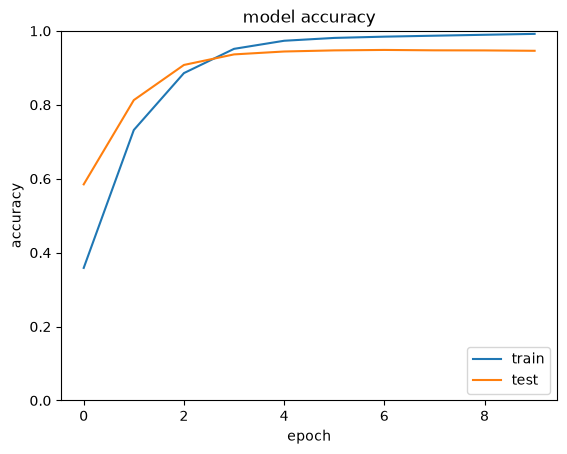

In [65]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

### Exercise 19
Retrain the model with an LSTM.
This should work faster, and yield better results.
Define, compile and fit your model.

In [66]:
model = build_tagger(LSTM(POS_UNITS, return_sequences=True), "pos_lstm")
model.summary()

Model: "pos_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 100, 100)       │     1,138,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 100, 13)        │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,181,985 (4.51 MB)

 Trainable params: 1,181,985 (4.51 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])

In [68]:
m_history = model.fit(X_train, y_train, epochs=POS_EPOCHS, batch_size=BATCH_SIZE,
                      validation_data=(X_test, y_test), verbose=2)
pos_results["LSTM"] = pos_token_accuracy(model, X_test, y_test)
print("Test token accuracy (non-padding): %.4f" % pos_results["LSTM"])
pos_models["LSTM"] = model

Epoch 1/10


49/49 - 17s - 354ms/step - acc: 0.2843 - loss: 2.3249 - val_acc: 0.2980 - val_loss: 2.1271


Epoch 2/10


49/49 - 17s - 348ms/step - acc: 0.4781 - loss: 1.7592 - val_acc: 0.7184 - val_loss: 1.2485


Epoch 3/10


...

Epoch 9/10


49/49 - 17s - 353ms/step - acc: 0.9828 - loss: 0.0668 - val_acc: 0.9434 - val_loss: 0.1805


Epoch 10/10


49/49 - 17s - 355ms/step - acc: 0.9836 - loss: 0.0595 - val_acc: 0.9452 - val_loss: 0.1769


Test token accuracy (non-padding): 0.9452


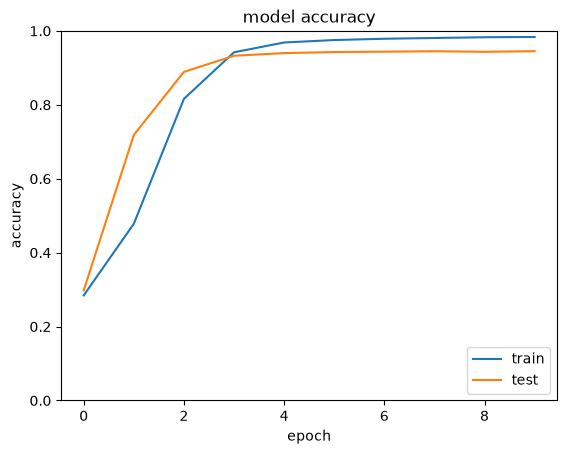

In [69]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

### Exercise 20
Retrain the model with a GRU.

In [70]:
model = build_tagger(GRU(POS_UNITS, return_sequences=True), "pos_gru")
model.summary()

Model: "pos_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 100, 100)       │     1,138,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 100, 64)        │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 100, 13)        │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,171,617 (4.47 MB)

 Trainable params: 1,171,617 (4.47 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])

In [72]:
m_history = model.fit(X_train, y_train, epochs=POS_EPOCHS, batch_size=BATCH_SIZE,
                      validation_data=(X_test, y_test), verbose=2)
pos_results["GRU"] = pos_token_accuracy(model, X_test, y_test)
print("Test token accuracy (non-padding): %.4f" % pos_results["GRU"])
pos_models["GRU"] = model

Epoch 1/10


49/49 - 16s - 325ms/step - acc: 0.3294 - loss: 2.2184 - val_acc: 0.4378 - val_loss: 1.7693


Epoch 2/10


49/49 - 15s - 314ms/step - acc: 0.7165 - loss: 1.1240 - val_acc: 0.8407 - val_loss: 0.6341


Epoch 3/10


...

Epoch 9/10


49/49 - 15s - 309ms/step - acc: 0.9823 - loss: 0.0565 - val_acc: 0.9457 - val_loss: 0.1680


Epoch 10/10


49/49 - 15s - 310ms/step - acc: 0.9836 - loss: 0.0515 - val_acc: 0.9457 - val_loss: 0.1680


Test token accuracy (non-padding): 0.9457


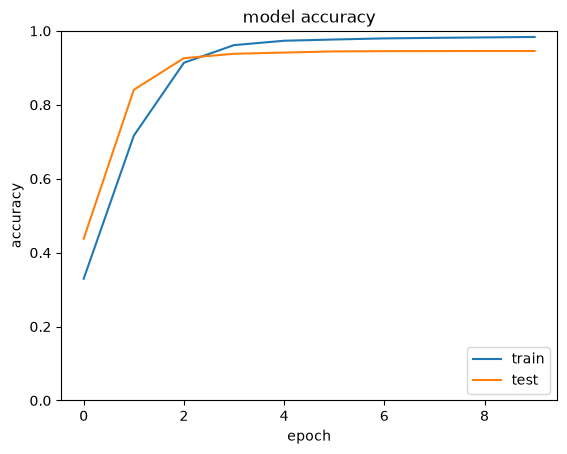

In [73]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

In [74]:
pos_summary = pd.Series(pos_results, name="test token accuracy").sort_values(ascending=False)
print(pos_summary.round(4))

best_name = pos_summary.index[0]
best_model = pos_models[best_name]

# per-tag report for the best model
pred = best_model.predict(X_test, verbose=0).argmax(-1)
true = y_test.argmax(-1)
mask = X_test != 0
tag_names = [tag_tokenizer.index_word[i] for i in range(1, num_classes)]
print(f"\nPer-tag report for the best model ({best_name}):")
print(classification_report(true[mask], pred[mask], labels=list(range(1, num_classes)),
                            target_names=tag_names, digits=3, zero_division=0))

SimpleRNN    0.9462
GRU          0.9457
LSTM         0.9452
Name: test token accuracy, dtype: float64



Per-tag report for the best model (SimpleRNN):
              precision    recall  f1-score   support

        NOUN      0.920     0.956     0.938      5624
        VERB      0.934     0.940     0.937      2696
           .      1.000     0.998     0.999      2327
         ADP      0.954     0.980     0.967      1878
         DET      0.986     0.968     0.977      1733
           X      0.998     0.973     0.986      1341
         ADJ      0.826     0.726     0.773      1265
         NUM      0.976     0.919     0.947       677
         PRT      0.962     0.974     0.968       696
         ADV      0.882     0.838     0.859       642
        PRON      0.996     1.000     0.998       558
        CONJ      0.998     0.991     0.994       442

    accuracy                          0.946     19879
   macro avg      0.953     0.939     0.945     19879
weighted avg      0.946     0.946     0.946     19879



**Discussion (POS tagging).** All three taggers reach ≈ 94.5–94.6% token accuracy on real (non-padding) test tokens, so on this dataset the cell type makes almost no difference. The exercise text expected the LSTM to be clearly better, but POS tagging depends mostly on the word itself and its immediate neighbours, which a SimpleRNN can capture just as well. The remaining errors are concentrated in ambiguous and rare classes (see the per-tag report, e.g. `ADJ` vs `NOUN`, `PRT` vs `ADP`, and `X`, which in the TreeBank consists of trace tokens such as `*-1`). Directions for improvement: a `Bidirectional` layer (the right context also disambiguates, e.g. *that* as `DET` vs `ADP`), pretrained or character-level embeddings for rare and unknown words, and more epochs with early stopping.

### Exercise 21
Save one of your models (the one with the best performance) as an h5 file. This is a straightforward operation, refer to [here](https://keras.io/api/models/model_saving_apis/).

You will use it on the **Advanced** part of the assignment to make inferences.

*The model alone is not enough for inference: the exact same word→index and index→tag mappings and the sequence length are needed, so they are saved next to the model.*

In [75]:
MODEL_PATH = MODEL_DIR / "pos_tagger.h5"
PREPROC_PATH = MODEL_DIR / "pos_tagger_preprocessing.json"

best_model.save(MODEL_PATH)
with open(PREPROC_PATH, "w", encoding="utf-8") as f:
    json.dump({
        "model": best_name,
        "max_len": POS_MAX_LEN,
        "word_tokenizer": word_tokenizer.to_json(),
        "tag_tokenizer": tag_tokenizer.to_json(),
    }, f)
print(f"Saved {best_name} tagger to {MODEL_PATH} and preprocessing to {PREPROC_PATH}")

Saved SimpleRNN tagger to models\pos_tagger.h5 and preprocessing to models\pos_tagger_preprocessing.json


---
# Part B — Advanced Inference
In this part of the advanced-level exercises, we will explore how to use our saved model to make predictions on unseen data.

*To demonstrate that the saved artefacts are self-contained, everything below only uses the files written in Exercise 21 (and the `Tokenizer` class definition) — nothing from the training kernel state.*

In [76]:
#Import the necessary libraries here
import os
os.environ["KERAS_BACKEND"] = "torch"
import json
from pathlib import Path
import numpy as np
import pandas as pd
import nltk
import keras
from keras.utils import pad_sequences
from nltk.tokenize import TreebankWordTokenizer

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

### Exercise 1
Refer to Keras again on how to load your saved model, [here](https://www.tensorflow.org/guide/keras/save_and_serialize).

In [77]:
tagger = keras.models.load_model("models/pos_tagger.h5")
with open("models/pos_tagger_preprocessing.json", encoding="utf-8") as f:
    preproc = json.load(f)
inf_word_tokenizer = Tokenizer.from_json(preproc["word_tokenizer"])
inf_tag_tokenizer = Tokenizer.from_json(preproc["tag_tokenizer"])
INF_MAX_LEN = preproc["max_len"]
print("Loaded", preproc["model"], "tagger; max_len =", INF_MAX_LEN)
tagger.summary()

Loaded SimpleRNN tagger; max_len = 100


Model: "pos_simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 100)       │     1,138,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 100, 64)        │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 13)        │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,307 (4.39 MB)

 Trainable params: 1,150,305 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (8.00 B)

In [78]:
Corpus=['The articles in this special section focus on using natural language generation techniques (NLG) and natural language processing (NLP) to build computational systems that generate reports and other kinds of text in human languages.',
        'NLG uses analytics, AI, and NLP to obtain relevant information about non-linguistic data and to generate textual summaries and explanations of these data which help people understand and benefit from them.',
        'In this regard, NLG is a research field that addresses the data-value chain by using natural language as a tool for bridging the gap between raw data and valuable information communicated to users in a comprehensible way, adapted to their information needs.']

a. We want to be able to tag the three sentences in the corpus above [source](https://ieeexplore.ieee.org/document/7983468).

Figure out the necessary steps that should precede passing the input into your **h5** model.

The input must go through exactly the same pipeline as the training data:

1. **Tokenise** each sentence the way the Penn TreeBank is tokenised — punctuation, brackets and clitics become separate tokens. NLTK's `TreebankWordTokenizer` implements these conventions. The TreeBank writes round brackets as `-LRB-` / `-RRB-`, so we map them to those forms, otherwise they would be unknown words.
2. **Encode** the tokens with the *training* word tokenizer (lower-cased; words never seen in training map to the `<OOV>` index).
3. **Pad** to the same number of time steps (`max_len`) with `"post"` padding (longer sentences would be truncated; ours are all shorter).

In [79]:
TREEBANK_BRACKETS = {"(": "-LRB-", ")": "-RRB-", "[": "-LSB-", "]": "-RSB-", "{": "-LCB-", "}": "-RCB-"}
treebank_tokenizer = TreebankWordTokenizer()

def preprocess(sentences):
    tokens = [treebank_tokenizer.tokenize(s) for s in sentences]
    model_tokens = [[TREEBANK_BRACKETS.get(t, t) for t in sent] for sent in tokens]
    encoded = inf_word_tokenizer.texts_to_sequences(model_tokens)
    padded = pad_sequences(encoded, maxlen=INF_MAX_LEN, padding="post", truncating="post")
    return tokens, encoded, padded

corpus_tokens, corpus_encoded, corpus_padded = preprocess(Corpus)

oov_id = inf_word_tokenizer.word_index["<OOV>"]
for sent, enc in zip(corpus_tokens, corpus_encoded):
    oov_words = [w for w, i in zip(sent, enc) if i == oov_id]
    print(f"{len(sent)} tokens, {len(oov_words)} unknown to the tagger: {oov_words}")
print(corpus_padded.shape)

39 tokens, 3 unknown to the tagger: ['NLG', 'NLP', 'computational']
34 tokens, 8 unknown to the tagger: ['NLG', 'analytics', 'NLP', 'relevant', 'non-linguistic', 'textual', 'summaries', 'explanations']
45 tokens, 6 unknown to the tagger: ['NLG', 'data-value', 'bridging', 'gap', 'communicated', 'comprehensible']
(3, 100)


b. Use the model to make the predictions on this dataset

In [80]:
probabilities = tagger.predict(corpus_padded, verbose=0)   # (sentences, time steps, classes)
predicted_ids = probabilities.argmax(axis=-1)
print(probabilities.shape)
print(predicted_ids[0][:len(corpus_tokens[0])])

(3, 100, 13)
[ 5  1  4  5  7  1  1  4  2  1  1  1  1  3  1  3 12  7  1  1  3  1  3  9
  2  1  1  4  2  1 12  7  1  4  1  4  7  1  3]


c. Tag the corpus above

*Only the first `len(sentence)` time steps are real tokens; the rest is padding and is discarded. Class 0 (padding) is never a valid tag, so it is excluded when taking the arg-max.*

In [81]:
tagged_corpus = []
for s_id, sent in enumerate(corpus_tokens):
    n = min(len(sent), INF_MAX_LEN)
    ids = probabilities[s_id, :n, 1:].argmax(-1) + 1        # skip padding class 0
    conf = probabilities[s_id, np.arange(n), ids]
    tagged_corpus.append([(w, inf_tag_tokenizer.index_word[int(i)], float(c))
                          for w, i, c in zip(sent, ids, conf)])

for s_id, tagged in enumerate(tagged_corpus, 1):
    print(f"Sentence {s_id}:")
    print(" ".join(f"{w}/{t}" for w, t, _ in tagged), "\n")

Sentence 1:
The/DET articles/NOUN in/ADP this/DET special/ADJ section/NOUN focus/NOUN on/ADP using/VERB natural/NOUN language/NOUN generation/NOUN techniques/NOUN (/. NLG/NOUN )/. and/CONJ natural/ADJ language/NOUN processing/NOUN (/. NLP/NOUN )/. to/PRT build/VERB computational/NOUN systems/NOUN that/ADP generate/VERB reports/NOUN and/CONJ other/ADJ kinds/NOUN of/ADP text/NOUN in/ADP human/ADJ languages/NOUN ./. 

Sentence 2:
NLG/NOUN uses/VERB analytics/NOUN ,/. AI/VERB ,/. and/CONJ NLP/NOUN to/PRT obtain/VERB relevant/ADJ information/NOUN about/ADP non-linguistic/NUM data/NOUN and/CONJ to/PRT generate/VERB textual/NOUN summaries/NOUN and/CONJ explanations/NOUN of/ADP these/DET data/NOUN which/DET help/NOUN people/NOUN understand/VERB and/CONJ benefit/VERB from/ADP them/PRON ./. 

Sentence 3:
In/ADP this/DET regard/NOUN ,/. NLG/NOUN is/VERB a/DET research/NOUN field/NOUN that/ADP addresses/NOUN the/DET data-value/ADJ chain/NOUN by/ADP using/VERB natural/NOUN language/NOUN as/ADP a/DE

*Sanity check (not part of the assignment): compare our tagger with NLTK's pretrained averaged-perceptron tagger mapped to the same universal tagset. Agreement is not ground truth, but disagreements point at the tokens worth inspecting.*

In [82]:
for pkg in ("averaged_perceptron_tagger_eng", "universal_tagset"):
    nltk.download(pkg, quiet=True)

rows = []
for s_id, tagged in enumerate(tagged_corpus, 1):
    ref = nltk.pos_tag([w for w, _, _ in tagged], tagset="universal")
    for pos, ((w, t, c), (_, r)) in enumerate(zip(tagged, ref), 1):
        rows.append({"sentence_id": s_id, "position": pos, "token": w, "predicted_tag": t,
                     "confidence": round(c, 4), "nltk_tag": r,
                     "known_word": inf_word_tokenizer.word_index.get(TREEBANK_BRACKETS.get(w, w).lower()) is not None})
predictions_df = pd.DataFrame(rows)
print("Agreement with NLTK perceptron tagger: %.1f%%" % (100 * (predictions_df.predicted_tag == predictions_df.nltk_tag).mean()))
print("Agreement on known words:   %.1f%%" % (100 * (predictions_df.predicted_tag == predictions_df.nltk_tag)[predictions_df.known_word].mean()))
print("Agreement on unknown words: %.1f%%" % (100 * (predictions_df.predicted_tag == predictions_df.nltk_tag)[~predictions_df.known_word].mean()))
predictions_df[predictions_df.predicted_tag != predictions_df.nltk_tag]

Agreement with NLTK perceptron tagger: 88.1%
Agreement on known words:   92.1%
Agreement on unknown words: 64.7%


,sentence_id,position,token,predicted_tag,confidence,nltk_tag,known_word
9,1,10,natural,NOUN,0.8846,ADJ,True
25,1,26,computational,NOUN,0.2519,ADJ,False
27,1,28,that,ADP,0.7749,DET,True
43,2,5,AI,VERB,0.9428,NOUN,True
52,2,14,non-linguistic,NUM,0.3301,ADJ,False
57,2,19,textual,NOUN,0.7581,ADJ,False
65,2,27,help,NOUN,0.9075,VERB,True
82,3,10,that,ADP,0.7440,DET,True
83,3,11,addresses,NOUN,0.5864,VERB,True
89,3,17,natural,NOUN,0.8931,ADJ,True


**Discussion (inference).** The tagger handles the function words and the frequent content words well (`The/DET`, `in/ADP`, `to/PRT`, `and/CONJ`, `them/PRON`, punctuation). Most mistakes fall on words that were **unknown** in the TreeBank vocabulary: agreement with NLTK's tagger is ~92% on known words but only ~65% on unknown words. All unknown words map to the same `<OOV>` embedding, so the model can only guess them from context (e.g. *non-linguistic/NUM*, *textual/NOUN*, *comprehensible/NOUN*). There are also genuine ambiguities in known words: *help* (VERB tagged NOUN), *users* (NOUN tagged VERB after *to*), and *natural* (ADJ tagged NOUN before *language*). This is the price of a word-level model trained on ~100k tokens of 1980s Wall Street Journal text applied to NLG/AI vocabulary. Character-level features or pretrained embeddings would reduce the OOV problem.

d. Save the corpus and the predictions on a file, and upload it with your submission on Canvas.

In [83]:
# 1) one row per token (CSV) - convenient for inspection / grading
predictions_df.drop(columns="nltk_tag").to_csv(OUTPUT_DIR / "corpus_pos_predictions.csv", index=False)

# 2) the corpus with its tags in the classic word/TAG format, one sentence per block
with open(OUTPUT_DIR / "corpus_pos_predictions.txt", "w", encoding="utf-8") as f:
    for s_id, (sentence, tagged) in enumerate(zip(Corpus, tagged_corpus), 1):
        f.write(f"# Sentence {s_id}: {sentence}\n")
        f.write(" ".join(f"{w}/{t}" for w, t, _ in tagged) + "\n\n")

print(open(OUTPUT_DIR / "corpus_pos_predictions.txt", encoding="utf-8").read())
print("Files written:", sorted(p.name for p in OUTPUT_DIR.iterdir()))

# Sentence 1: The articles in this special section focus on using natural language generation techniques (NLG) and natural language processing (NLP) to build computational systems that generate reports and other kinds of text in human languages.
The/DET articles/NOUN in/ADP this/DET special/ADJ section/NOUN focus/NOUN on/ADP using/VERB natural/NOUN language/NOUN generation/NOUN techniques/NOUN (/. NLG/NOUN )/. and/CONJ natural/ADJ language/NOUN processing/NOUN (/. NLP/NOUN )/. to/PRT build/VERB computational/NOUN systems/NOUN that/ADP generate/VERB reports/NOUN and/CONJ other/ADJ kinds/NOUN of/ADP text/NOUN in/ADP human/ADJ languages/NOUN ./.

# Sentence 2: NLG uses analytics, AI, and NLP to obtain relevant information about non-linguistic data and to generate textual summaries and explanations of these data which help people understand and benefit from them.
NLG/NOUN uses/VERB analytics/NOUN ,/. AI/VERB ,/. and/CONJ NLP/NOUN to/PRT obtain/VERB relevant/ADJ information/NOUN about/ADP n